## Creating rolling loops

In [1]:
import os

os.chdir("C:/Users/finle/Dev/Dissertation")

In [2]:

from pandas import Series
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.models import rolling_garch_var
spy = pd.read_csv("data/SPY_data.csv", index_col=0, parse_dates=True)

log_returns = spy['log_returns'].fillna(0)
type(log_returns)
spy.index
type(log_returns.index)


pandas.core.indexes.datetimes.DatetimeIndex

Historical VaR


In [5]:
def VaR_historical_rolling(
    ts: Series, 
    window: int,
    confidence: float =0.99
    ):
    if confidence >= 0.9999:
        raise ValueError(f"Confidence must be below 1. you entered {confidence}")
    VaR = - ts.rolling(window,min_periods=50).quantile(1-confidence).shift(1)
    return VaR


historical_rolling_95 = VaR_historical_rolling(log_returns, 500, 0.95)
historical_rolling_99 = VaR_historical_rolling(log_returns, 500, 0.99)

rolling_forecasts =  pd.DataFrame({'historical_rolling_95': historical_rolling_95,
             'historical_rolling_99':historical_rolling_99})

ewma

In [6]:
from scipy.stats import norm

def ewma_rolling_var(
    returns:Series,
    lam: float = 0.94,
    alpha: float = 0.01,
    confidence: float = 0.99):
    """
    Parameters
    ----------
    lam: float
        Decay parameter. Riskmetrics uses 0.94 for daily data.
    alpha: float   
        Tail probability.
        
    Returns
    -------
    """
    r = np.array(returns)
    T = len(r)
    var = np.zeros(T)
    var[0] = np.var(r[:30])
    
    for t in range(1,T):
        var[t] = lam * var[t-1] + (1 - lam) * r[t-1] ** 2
        
    sigma = np.sqrt(var)
    VaR = -(np.mean(r) + sigma * norm.ppf(1 - confidence))
    return VaR

ewma_rolling_95 = ewma_rolling_var(log_returns, confidence=0.95)
ewma_rolling_99 = ewma_rolling_var(log_returns, confidence=0.99)

rolling_forecasts['ewma_rolling_95'] = ewma_rolling_95
rolling_forecasts['ewma_rolling_99'] = ewma_rolling_99
rolling_forecasts.to_csv("data/historical_rolling_forecasts.csv")

GARCH Rolling VaR

In [3]:
garch_rolling_95_t = rolling_garch_var(
    log_returns,
    window=500,
    alpha=0.05,
    horizon=1,
    dist='t')

garch_rolling_99_t = rolling_garch_var(
    log_returns,
    window=500,
    alpha=0.01,
    horizon=1,
    dist='t')




Calculating rolling GARCH VaR: 100%|██████████| 4533/4533 [00:15<00:00, 284.30it/s]


normal based VaR

In [9]:
garch_rolling_95_n = rolling_garch_var(
    log_returns,
    window=500,
    alpha=0.05,
    horizon=1,
    dist='normal')

garch_rolling_99_n = rolling_garch_var(
    log_returns,
    window=500,
    alpha=0.01,
    horizon=1,
    dist='normal')


garch_results = pd.DataFrame({
    'returns': np.ravel(garch_rolling_95_t[2]),
    'garch_rolling_95_t':np.ravel(garch_rolling_95_t[1]),
    'garch_rolling_99_t':np.ravel(garch_rolling_99_t[1]),
    'garch_rolling_95_n':np.ravel(garch_rolling_95_n[1]),
    'garch_rolling_99_n':np.ravel(garch_rolling_99_n[1])
},
                             index=np.ravel(garch_rolling_95_t[0])
                             )



Calculating rolling GARCH VaR: 100%|██████████| 4533/4533 [00:11<00:00, 387.71it/s]


In [11]:
garch_results.to_csv("data/garch_rolling_forecasts.csv")

MS model

In [3]:
from src.models import rolling_ms_var

MS_rolling_var_95 = rolling_ms_var(log_returns, 2, window=500, alpha=0.05)

Rolling Markov Switching model loading: 100%|██████████| 4532/4532 [01:54<00:00, 39.70it/s]


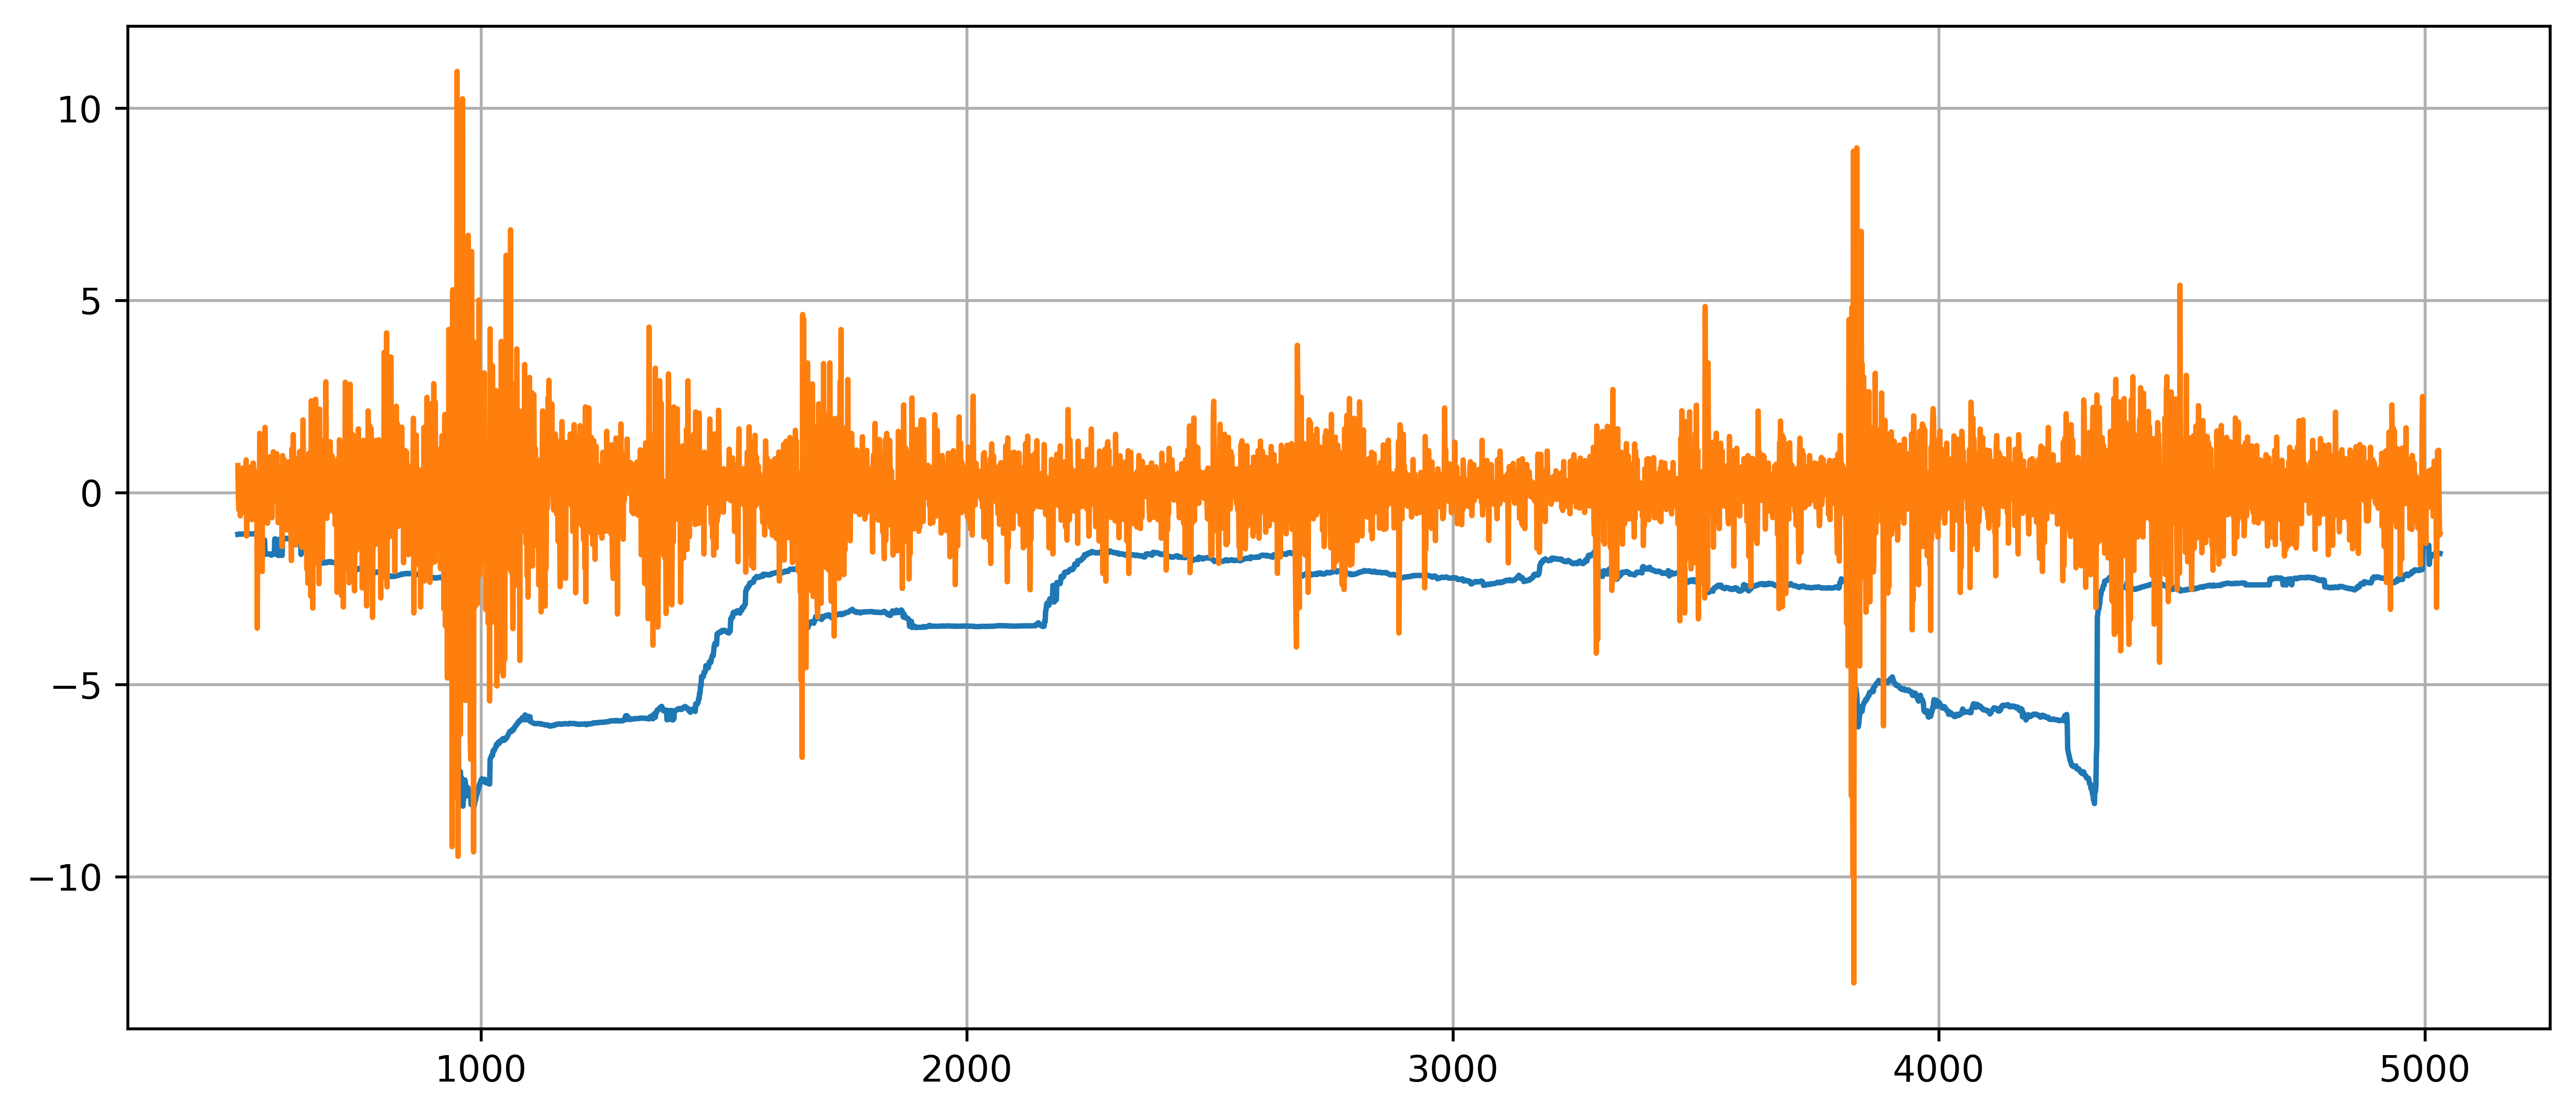

In [ ]:
fig, ax = plt.subplots(figsize=(12,5), dpi=600)

ax.plot(MS_rolling_var_95[0], -MS_rolling_var_95[1])
ax.plot(MS_rolling_var_95[0],MS_rolling_var_95[2])
ax.grid(True)


In [7]:
MS_rolling_var_99 = rolling_ms_var(
    log_returns,
    k_regimes=2,
    window=500,
    alpha=0.01,
    horizon=1)

Rolling Markov Switching model loading: 100%|██████████| 4532/4532 [01:50<00:00, 41.15it/s]


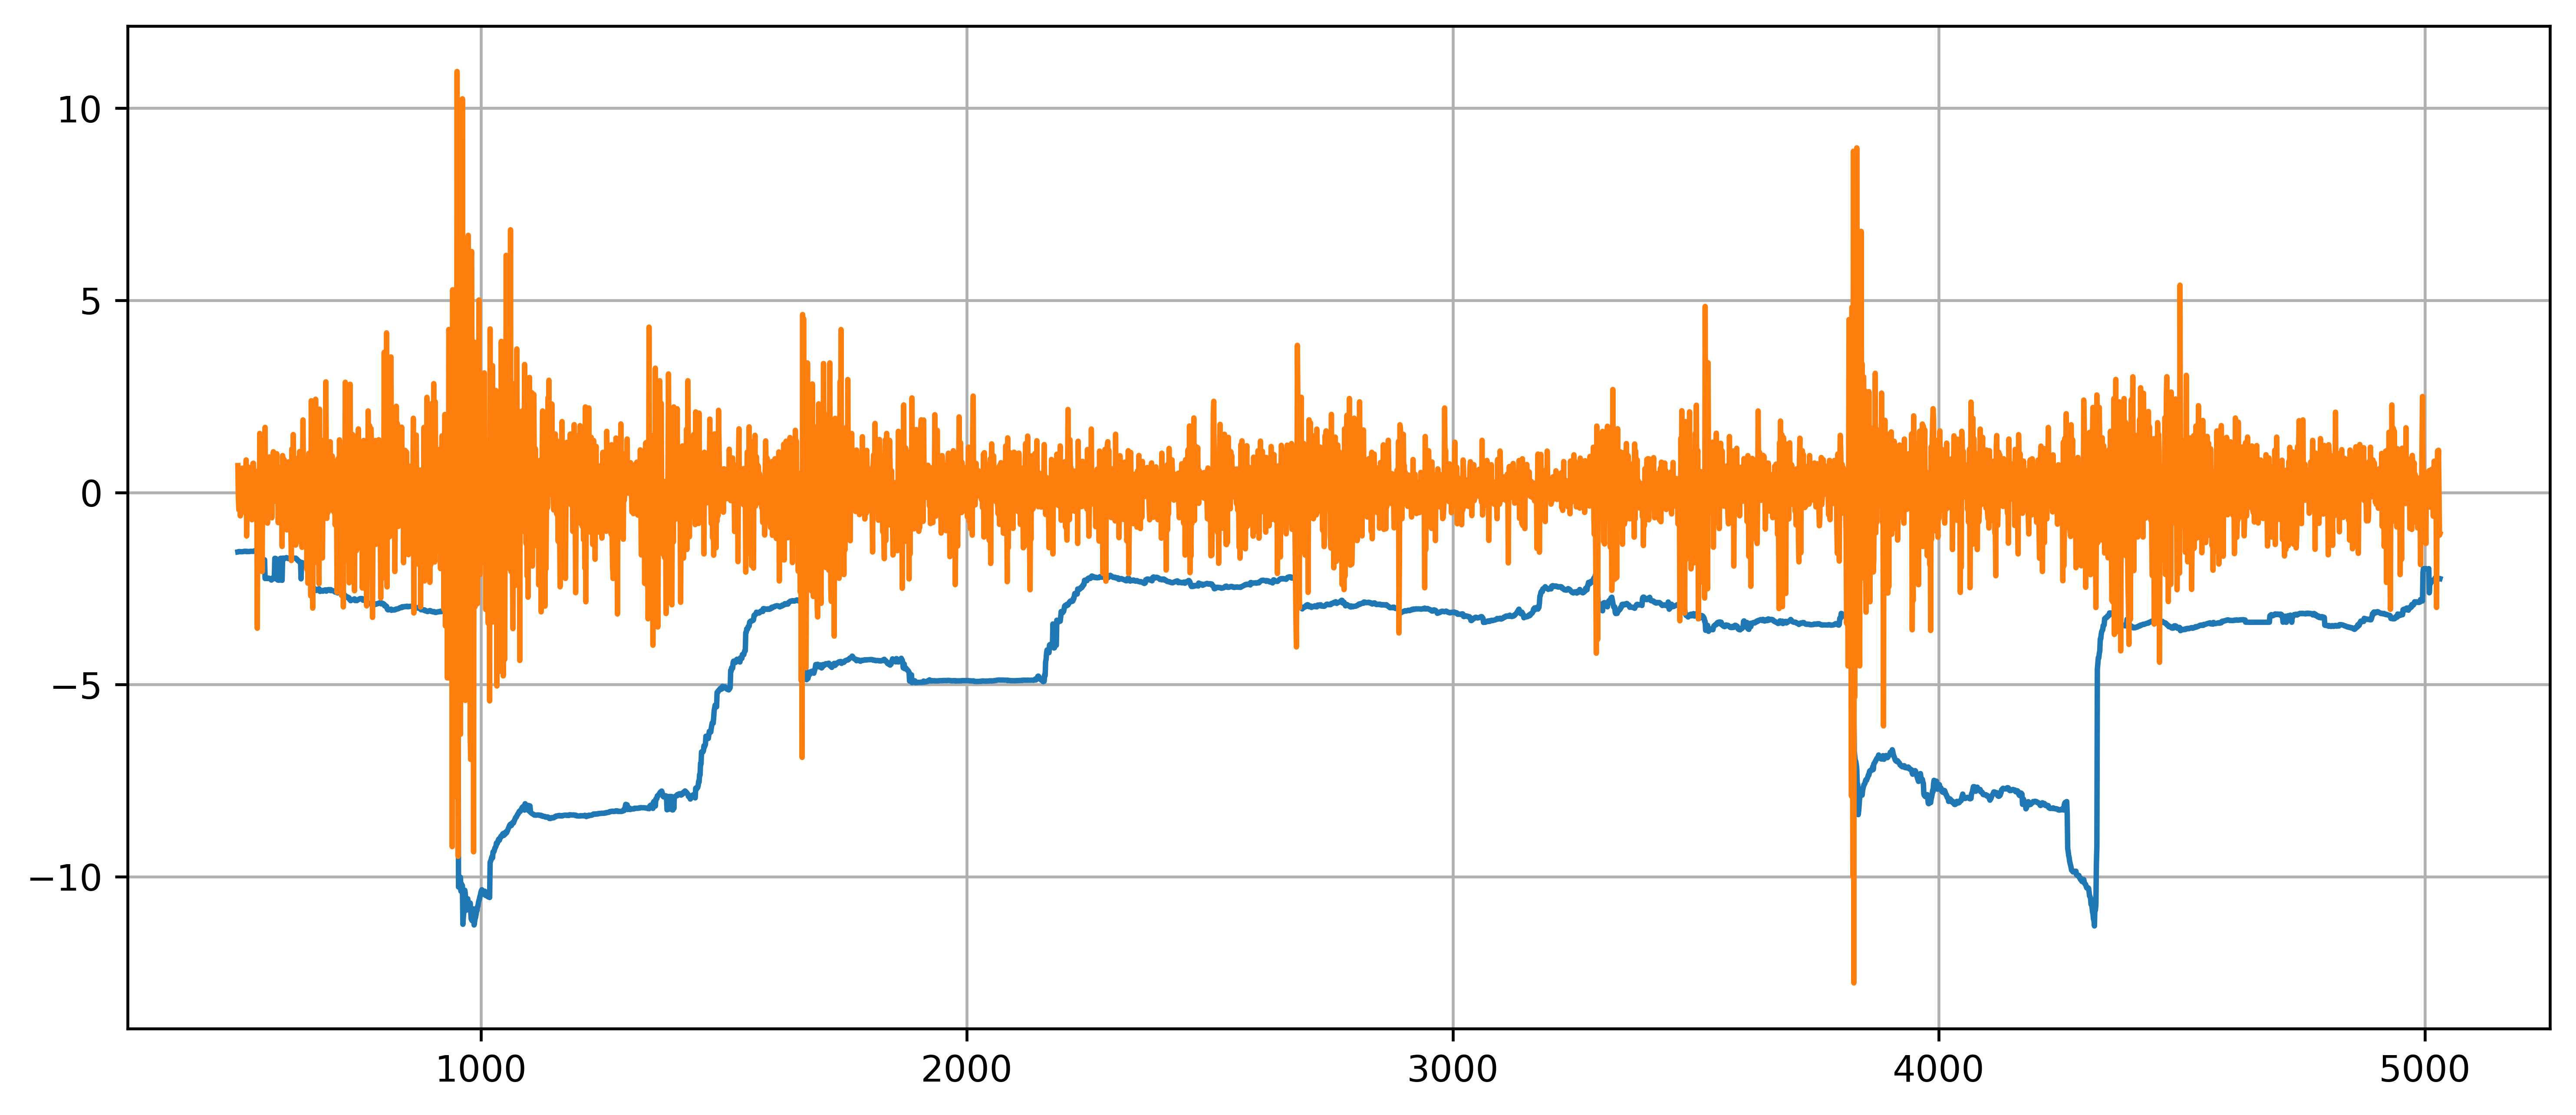

In [8]:
fig, ax = plt.subplots(figsize=(12,5), dpi=600)

ax.plot(MS_rolling_var_99[0], -MS_rolling_var_99[1])
ax.plot(MS_rolling_var_99[0],MS_rolling_var_99[2])
ax.grid(True)

MS-GARCH Model